# 기초통계 통합 프로젝트
## Part 4. 방문횟수를 이용한 구매금액 회귀예측

### 시나리오

Part 3에서는 월간 방문횟수와 구매금액의 산점도와 상관계수를 확인했습니다.

온라인 쇼핑몰 운영팀은 두 변수 사이의 관계를 확인하는 것에서 나아가,
고객의 월간 방문횟수를 이용하여 구매금액을 어느 정도 예측할 수 있는지 확인하려고 합니다.

분석팀은 방문횟수를 독립변수, 구매금액을 종속변수로 설정하여
가장 기본적인 단순 선형회귀 모델을 만들고 회귀계수와 R²를 해석해야 합니다.


### 과제 목표

#### 필수 목표
- 독립변수와 종속변수를 구분할 수 있습니다.
- 단순 선형회귀 모델을 학습할 수 있습니다.
- 회귀계수와 절편을 확인하고 회귀식을 작성할 수 있습니다.
- 회귀선을 산점도와 함께 시각화할 수 있습니다.
- R²를 계산하여 모델의 설명력을 해석할 수 있습니다.
- 새로운 방문횟수에 대한 구매금액을 예측할 수 있습니다.

#### 심화 목표
- 방문횟수 하나만 사용하는 단순회귀 모델의 한계를 설명할 수 있습니다.
- 구매금액 예측을 개선하기 위해 추가로 고려할 변수를 제안하고 이유를 설명할 수 있습니다.

### 사용 환경

- 결과물: `.ipynb` 파일 1개
- 사용 언어: Python 3.X
- 사용 라이브러리: pandas, matplotlib, scikit-learn
- 사용 데이터: `online_shopping_customer_data.csv`


## 제공 코드. 회귀분석 데이터 준비

아래 코드는 준비 코드이며 평가 대상이 아닙니다.

Part 3과 동일한 기준으로 `MonthlyVisitCount`, `PurchaseAmount`에 결측치가 없는 고객을 선택하여
회귀분석용 데이터 `relation_df`를 생성합니다.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

DATA_FILE = "online_shopping_customer_data.csv"

df = pd.read_csv(DATA_FILE)

regression_columns = ["MonthlyVisitCount","PurchaseAmount"]

relation_df = df.dropna(subset=regression_columns).copy()

print("회귀분석에 사용할 고객 수:", len(relation_df))

relation_df[regression_columns].head()


회귀분석에 사용할 고객 수: 487


,MonthlyVisitCount,PurchaseAmount
0,6.0,86900.0
1,10.0,287500.0
2,11.0,242100.0
3,15.0,300500.0
4,8.0,171400.0


# 문제 1. 독립변수와 종속변수 설정 및 회귀모델 학습

## 업무 상황

분석팀은 방문횟수를 이용하여 구매금액을 예측하는
단순 선형회귀 모델을 만들려고 합니다.

## 요구사항

1. `MonthlyVisitCount`를 독립변수 `X`로 설정합니다.
2. `PurchaseAmount`를 종속변수 `y`로 설정합니다.
3. `LinearRegression` 모델을 생성합니다.
4. 전체 데이터를 이용하여 모델을 학습합니다.
5. 학습에 사용한 `X`, `y`의 크기를 출력합니다.

## 힌트

- scikit-learn의 독립변수는 하나의 컬럼이라도 2차원 형태로 작성합니다.
- `X = relation_df[["MonthlyVisitCount"]]`와 같이 이중 대괄호를 사용할 수 있습니다.


In [8]:
# 문제 1 코드를 작성하세요.
x = relation_df[["MonthlyVisitCount"]]
y = relation_df[["PurchaseAmount"]]
model = LinearRegression()
model.fit(x, y)

print("x 방문횟수:", len(x))
print("y 결제금액:", len(y))

x 방문횟수: 487
y 결제금액: 487


# 문제 2. 회귀계수·절편 확인 및 회귀선 시각화

## 업무 상황

운영팀은 방문횟수가 한 번 증가할 때
예측 구매금액이 얼마나 변하는지 확인하고 싶어 합니다.

## 요구사항

1. 학습된 모델의 회귀계수를 출력합니다.
2. 학습된 모델의 절편을 출력합니다.
3. 다음 형태로 회귀식을 작성합니다.

   `예측 구매금액 = 절편 + 회귀계수 × 방문횟수`

4. 실제 고객 데이터의 산점도를 생성합니다.
5. 산점도 위에 학습된 회귀선을 표시합니다.
6. 회귀계수의 의미를 한 문장으로 작성합니다.


절편: 26060.04
기울기: 19052.65
예측 구매금액 = 26060.04 + 19052.65 × 방문횟수


C:\Users\jhj31\AppData\Local\Temp\ipykernel_33432\3617875164.py:21: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jhj31\AppData\Local\Temp\ipykernel_33432\3617875164.py:21: UserWarning: Glyph 44480 (\N{HANGUL SYLLABLE GWI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jhj31\AppData\Local\Temp\ipykernel_33432\3617875164.py:21: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\exe_2\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\exe_2\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44480 (\N{HANGUL SYLLABLE GWI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\exe_2\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49440 (\N

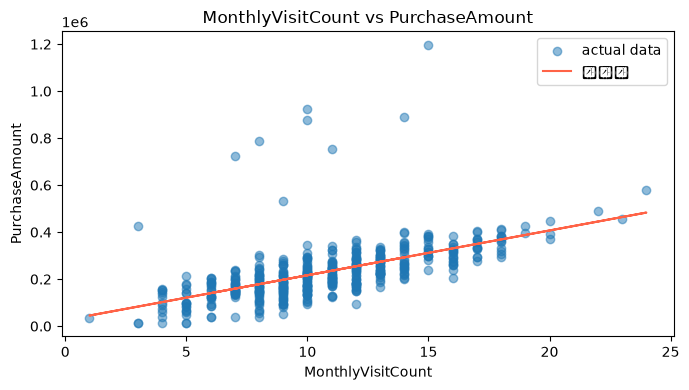

In [16]:
# 문제 2 코드를 작성하세요.
x = relation_df[["MonthlyVisitCount"]]
y = relation_df["PurchaseAmount"]
model = LinearRegression()
model.fit(x, y)

# print("x 방문횟수:", len(x))
# print("y 결제금액:", len(y))

print(f"절편: {model.intercept_:.2f}")
print(f"기울기: {model.coef_[0]:.2f}")
print(f"예측 구매금액 = {model.intercept_:.2f} + {model.coef_[0]:.2f} × 방문횟수")

plt.figure(figsize=(7, 4))
plt.scatter(relation_df["MonthlyVisitCount"], relation_df["PurchaseAmount"], alpha=0.5, label="actual data")
plt.plot(relation_df["MonthlyVisitCount"],model.predict(x), color='tomato', label='회귀선')
plt.xlabel('MonthlyVisitCount')
plt.ylabel('PurchaseAmount')
plt.title('MonthlyVisitCount vs PurchaseAmount')
plt.legend()
plt.tight_layout()
plt.show()

# 문제 3. 모델 설명력 평가 및 구매금액 예측

## 업무 상황

분석팀은 방문횟수 하나만으로 구매금액을 얼마나 설명할 수 있는지 확인하고,
새로운 방문횟수에 대한 예상 구매금액을 계산하려고 합니다.

## 요구사항

1. 전체 고객의 예측 구매금액을 계산합니다.
2. 실제 구매금액과 예측 구매금액을 이용하여 R²를 계산합니다.
3. 방문횟수 5회, 10회, 15회에 대한 구매금액을 예측합니다.
4. 방문횟수와 예측 구매금액을 하나의 표로 정리합니다.
5. R²가 의미하는 내용을 한두 문장으로 설명합니다.

## R² 해석

- R²는 모델이 구매금액의 변동을 어느 정도 설명하는지 나타냅니다.
- R²가 1에 가까울수록 모델의 설명력이 높습니다.
- R²가 낮으면 방문횟수만으로 구매금액의 변동을 충분히 설명하기 어렵다는 의미입니다.


In [17]:
# 문제 3 코드를 작성하세요.
y_pred = model.predict(x)
r2 = r2_score(y, y_pred)
print(f"R²: {r2:.4f}")

# 3. 회귀식에 방문횟수를 직접 넣어 예측
beta0 = model.intercept_
beta1 = model.coef_[0]

pred_5 = beta0 + beta1 * 5
pred_10 = beta0 + beta1 * 10
pred_15 = beta0 + beta1 * 15

print(f"방문횟수 5회 예측 구매금액: {pred_5:.2f}")
print(f"방문횟수 10회 예측 구매금액: {pred_10:.2f}")
print(f"방문횟수 15회 예측 구매금액: {pred_15:.2f}")

# 4. 하나의 표로 정리
predict_df = pd.DataFrame([{"방문횟수": 5, "예측 구매금액": pred_5},
                           {"방문횟수": 10, "예측 구매금액": pred_10},
                           {"방문횟수": 15, "예측 구매금액": pred_15}])

predict_df

R²: 0.3312
방문횟수 5회 예측 구매금액: 121323.31
방문횟수 10회 예측 구매금액: 216586.57
방문횟수 15회 예측 구매금액: 311849.84


,방문횟수,예측 구매금액
0,5,121323.308448
1,10,216586.573404
2,15,311849.838360


# 문제 4. 단일 변수 회귀모델의 한계와 추가 변수 제안

## 업무 상황

현재 모델은 `MonthlyVisitCount` 하나만 사용하여 `PurchaseAmount`를 예측합니다.
운영팀은 이 모델을 전체 고객의 구매금액 예측에 바로 활용해도 되는지 검토하려고 합니다.

## 요구사항

1. 방문횟수 하나만 사용하는 모델이 구매금액을 충분히 설명하지 못할 수 있는 이유를 작성합니다.
2. 구매금액 예측에 추가로 고려할 변수 **2개 이상**을 제안합니다.
3. 제안한 각 변수가 구매금액과 어떤 관련이 있을 수 있는지 간단히 설명합니다.
4. 현재 모델을 실제 업무에 적용하기 전에 추가로 확인할 사항을 한 가지 작성합니다.

> 이 문제는 별도의 추가 모델 구현이 아니라 **해석과 변수 제안**을 평가합니다.


# 심화 문제 4의 해석을 마크다운 셀에 작성하세요.
1. 구매금액 차이를 방문횟수로만 설명하기가 어렵다. 같은 방문횟수여도 비싼걸 사는 고객일수도, 싼걸 사는 고객일수도 있기 때문이다.
2. 평균 상품가격, 구매수량
3. 평균 상품가격 : 비싼 상품을 구매하면 금액이 커진다. 구매수량 : 수량이 많을수록 금액이 커진다.
4. 실제 구매금액과 예측한 구매금액의 차이를 확인한다.

# 제출 결과물

## 필수 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 회귀분석 데이터 | 독립변수 `X`, 종속변수 `y` |
| 모델 학습 결과 | 단순 선형회귀 모델 |
| 회귀식 | 회귀계수와 절편 |
| 회귀 시각화 | 고객 산점도와 회귀선 |
| 모델 평가 | R²와 설명력 해석 |
| 예측 결과 | 방문횟수 5회, 10회, 15회의 예측 구매금액 |
| 필수 해석 | 회귀계수와 R²의 의미 |

## 심화 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 모델 한계 | 방문횟수 하나만 사용하는 모델의 한계 |
| 추가 변수 제안 | 구매금액 예측에 활용할 변수 2개 이상과 선정 이유 |
| 적용 전 확인 사항 | 실제 업무 적용 전에 검토할 사항 |

# 제출 전 체크리스트

## 필수 체크리스트
- [ ] 독립변수와 종속변수를 올바르게 설정했습니다.
- [ ] 단순 선형회귀 모델을 학습했습니다.
- [ ] 회귀계수와 절편을 출력했습니다.
- [ ] 회귀식을 작성했습니다.
- [ ] 산점도와 회귀선을 함께 표시했습니다.
- [ ] R²를 계산하고 의미를 설명했습니다.
- [ ] 새로운 방문횟수의 구매금액을 예측했습니다.
- [ ] 회귀계수의 의미를 설명했습니다.

## 심화 체크리스트
- [ ] 방문횟수 하나만 사용하는 모델의 한계를 설명했습니다.
- [ ] 추가로 고려할 변수 2개 이상을 제안했습니다.
- [ ] 각 변수의 선정 이유를 설명했습니다.
- [ ] 실제 적용 전에 확인할 사항을 작성했습니다.
